# Exploration du WARC Marsactu (j1 - 2011 à 2015)

## But de cette exploration

Avant de faire de l'analyse sémantique sur le corpus, je veux comprendre ce qu'il y a dans le fichier WARC qu'on a reçu de la BnF. L'idée c'est de regarder la matière brute, pour ne pas partir tête baissée sur des données que je ne connais pas.

Dans ce notebook je regarde combien il y a de records et de quels types, qui a fait le crawl et sur quelle période, comment les captures sont réparties dans le temps, s'il y a des doublons ou des choses à filtrer, et quels formats de fichiers sont présents. À la fin je dois pouvoir décrire le corpus précisément et avoir noté les décisions de filtrage à faire avant de construire le DataFrame de travail.

In [209]:
from warcio.archiveiterator import ArchiveIterator
from pathlib import Path 
from collections import Counter
import re
import matplotlib.pyplot as plt
from datetime import datetime


In [210]:
# Chemin vers le fichier WARC
WARC_PATH = Path("../data/raw/bnf-marsactu-2011-2015.pfvd.ux.bnf.fr.warc.gz")

if WARC_PATH.exists():
    print("Fichier trouvé !!")
    taille_mo = WARC_PATH.stat().st_size / (1024**2)
    print(f"Taille du fichier: {taille_mo: .1f} Mo")
else:
    print("Fichier non trouvé !!")
   

Fichier trouvé !!
Taille du fichier:  419.5 Mo


In [211]:
# Nombre de records
# Types de records

nb_records = 0
record_types_counter = Counter()

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        
        nb_records += 1
        
        record_types_counter[f"{record.rec_type}"] += 1
        

        

print(f"Nombre total de records: {nb_records}")
print(record_types_counter.most_common(4))


Nombre total de records: 23470
[('response', 23469), ('warcinfo', 1)]


Au total le WARC contient 23 470 records, dont 1 qui est de type `warcinfo` (c'est l'en-tête du fichier WARC, donc pas très utile pour notre analyse sémantique des pages) et les 23 469 records restants sont des `response` HTTP. Chaque enregistrement de type `response` constitue une capture fidèle d'une ressource web à un instant T. Plus précisément, il contient l'intégralité de la réponse HTTP renvoyée par le serveur, incluant les métadonnées de transmission et, surtout, le payload HTML.

#### Important :
On travaille donc sur les 23 469 records.

In [212]:
# Lecture du warcinfo
warcinfo_contenu = ""
with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type == "warcinfo":
            contenu_bytes = record.content_stream().read()
            contenu_texte = contenu_bytes.decode("utf-8")
            warcinfo_contenu = contenu_texte
            print(contenu_texte)

hostname: delaware.pfvd.ux.bnf.fr
software: website-recover/3.0.0PFC30
ip: 172.20.90.124
format: WARC File Format 1.0
publisher: Bibliotheque nationale de France
description: Ce corpus correspond aux premières archives du site marsactu.fr constituées par la Bibliothèque nationale de France entre le 1er janvier 2011et le 31 décembre 2015.
conformsTo: http://bibnum.bnf.fr/WARC/WARC_ISO_28500_version1_latestdraft.pdf
operator: BnF - DLWeb



#### Ce qu'on apprend du warcinfo

Le crawler utilisé est `website-recover/3.0.0PFC30`, un outil propriétaire de la BnF. On n'a pas accès à son code donc on ne peut pas voir exactement comment il a parcouru le site. C'est une opacité à signaler dans le rapport.

La description annonce la période du 1er janvier 2011 au 31 décembre 2015, mais on va voir plus bas que la première capture réelle date de septembre 2011. Il y a donc un décalage entre la doc officielle et la réalité du fichier.

L'opérateur est BnF - DLWeb (Département du Dépôt Légal Numérique), c'est le service à contacter pour les questions sur le corpus.

Avant d'analyser le contenu de chacun de ces records, on doit savoir si le contenu de chacun des 23 469 records est pertinent pour notre étude. Il faut donc qu'on puisse visualiser les différents records, vérifier s'ils sont tous exploitables et s'il n'existe pas de doublons.

On peut remarquer que dans chaque record, il y a une date d'enregistrement du record (`WARC-Date`). Il serait donc intéressant de voir la distribution temporelle des captures de l'ensemble des records dans notre WARC j1-marsactu.

Nombre de dates collectées : 23469
Première capture : 2011-09-16 18:19:10
Dernière capture : 2015-12-30 14:26:27


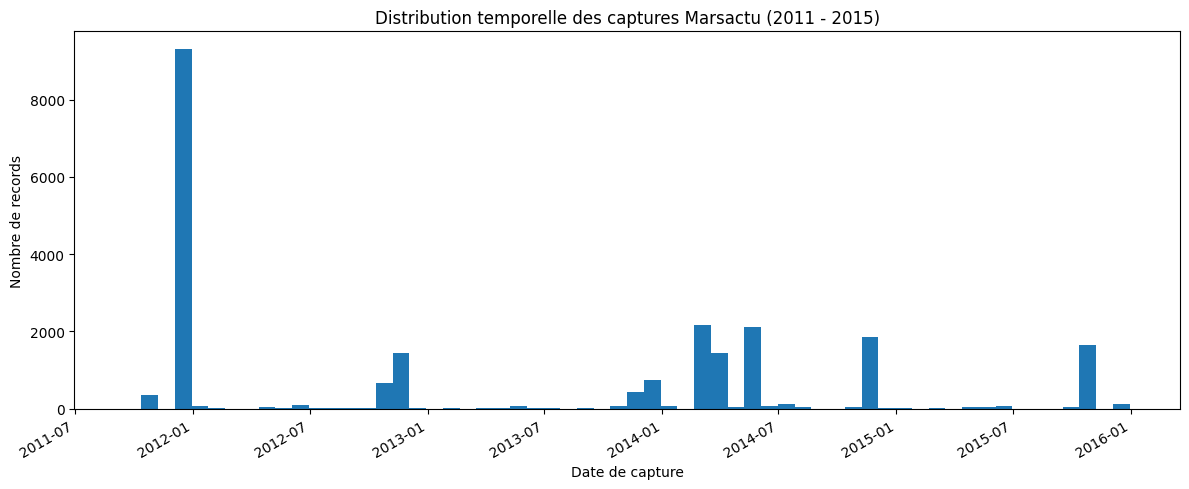

In [213]:
# Distribution temporelle des captures

dates_captures = []

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type == "warcinfo":
            continue
        date_str = record.rec_headers.get_header("WARC-Date")
        date_obj = datetime.fromisoformat(date_str.replace("Z", ""))
        dates_captures.append(date_obj)
        


print(f"Nombre de dates collectées : {len(dates_captures)}")
print(f"Première capture : {min(dates_captures)}")
print(f"Dernière capture : {max(dates_captures)}")                              
                                
fig, ax = plt.subplots(figsize=(12,5))

ax.hist(dates_captures, bins=60)
ax.set_title("Distribution temporelle des captures Marsactu (2011 - 2015)")
ax.set_xlabel("Date de capture")
ax.set_ylabel("Nombre de records")
fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('distribution-temporelle-captures-j1-marsactu.png')
plt.show()


                                                 

                                                 
                                                 

        

#### Remarque :
Le corpus j1 de Marsactu présente une distribution temporelle très inégale, avec environ 40% des records enregistrés en janvier 2012, suggérant que la BnF ait fait une capture initiale massive de l'intégralité du site Marsactu existant à ce moment-là. L'analyse diachronique ne devra pas reposer sur la date de capture mais plutôt sur la date de publication, qu'on retrouvera dans l'URL ou dans le HTML des articles.

In [214]:
# Vérifions que la conjecture faite sur la capture du Janvier 2012 soit une capture massive. 

echantillons_jan_2012 = []
with open(WARC_PATH, 'rb') as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
            
        date_str = record.rec_headers.get_header("WARC-Date")

        if not date_str.startswith("2012-01"):
            continue

        url = record.rec_headers.get_header("WARC-Target-URI")

        html_bytes = record.content_stream().read()

        echantillons_jan_2012.append({
            "url": url,
            "date_capture": date_str, 
            "html": html_bytes
        })

        if len(echantillons_jan_2012) >= 20:
            break


print(f"echantillons collectés: {len(echantillons_jan_2012)}")
            

        

echantillons collectés: 20


In [215]:
for i, ech in enumerate(echantillons_jan_2012):
    print(f"[{i}] {ech['date_capture']} -> {ech['url']}")
# En regardant les dates dans les URLs.
# On retrouve des pages capturées datant de 2009 à 2011.
# On peut donc supposer que la capture de janvier 2012 était une capture de tout l'historique de Marsactu.

[0] 2012-01-24T11:28:46Z -> http://www.marsactu.fr/2009/12/17/nathalie-simon-retrouve-lantenne/feed/
[1] 2012-01-24T11:29:03Z -> http://www.marsactu.fr/2009/12/22/le-tribunal-administratif-de-marseille-renvoie-michel-drucker-dans-son-canape/
[2] 2012-01-29T16:08:39Z -> http://www.marsactu.fr/2010/02/17/christophe-madrolle-va-t-il-traverser-le-vieux-port-a-la-nage/feed/
[3] 2012-01-29T16:09:14Z -> http://www.marsactu.fr/2010/02/17/des-musulmans-se-mobilisent-pour-restaurer-une-chapelle/
[4] 2012-01-29T16:08:48Z -> http://www.marsactu.fr/2010/02/17/margarita-louis-dreyfus-va-t-elle-preferer-lom-aux-paris-en-ligne/
[5] 2012-01-23T20:39:00Z -> http://www.marsactu.fr/2011/01/07/affaire-guerini-la-petite-fleur-objet-de-toutes-les-attentions-du-cg13/feed/
[6] 2012-01-23T20:45:33Z -> http://www.marsactu.fr/2011/01/07/cantonales-affaire-guerini-wikileaks13-menu-charge-pour-les-voeux-du-conseil-general/
[7] 2012-01-23T20:39:58Z -> http://www.marsactu.fr/2011/01/07/le-ras-le-bol-des-gens-du-voyag

### Remarque :
Ces URLs en `/feed/` correspondent au flux RSS des commentaires de chaque article (comportement par défaut de [WordPress](https://wordpress.com/support/feeds/)). Elles dupliquent les URLs des articles sans en contenir le texte. Pour l'analyse de la ligne éditoriale, on va probablement exclure les URLs contenant `/feed/` et ne garder que les flux d'articles principaux (sans `/feed/`).

On peut aussi remarquer des doublons générés : on a l'URL de l'article et l'URL + `/feed/`. Le crawler a donc capturé les deux versions du site.

### Référence :
- WordPress, [Find your RSS feed](https://wordpress.com/support/feeds/)

In [216]:
# Page d'un site avec un URL en /feed/

print(echantillons_jan_2012[8]['url'])
print(echantillons_jan_2012[8]['html'])

# Ce /feed/ est le flux RSS des commentaires de l'article et non le contenu de l'article lui-même.
# Le titre du flux le confirme : "Commentaires sur : Le ras-le-bol des gens du voyage...".
# Ici, les trois <item> ne sont pas des commentaires de lecteurs mais des trackbacks.
# Définition de trackback : notification automatique émise quand un autre site fait un lien vers cet article.
# Ces URLs /feed/ n'apportent aucun contenu éditorial exploitable pour notre analyse et seront filtrées du corpus.

http://www.marsactu.fr/2011/01/07/le-ras-le-bol-des-gens-du-voyage-devant-la-mairie-de-marseille/feed/
b'<?xml version="1.0" encoding="UTF-8"?><rss version="2.0" xmlns:content="http://purl.org/rss/1.0/modules/content/" xmlns:dc="http://purl.org/dc/elements/1.1/" xmlns:atom="http://www.w3.org/2005/Atom" xmlns:sy="http://purl.org/rss/1.0/modules/syndication/" xmlns:georss="http://www.georss.org/georss" xmlns:media="http://search.yahoo.com/mrss/"\t> <channel><title>Commentaires sur : Le ras-le-bol des gens du voyage devant la mairie de Marseille</title> <atom:link href="http://www.marsactu.fr/2011/01/07/le-ras-le-bol-des-gens-du-voyage-devant-la-mairie-de-marseille/feed/" rel="self" type="application/rss+xml" /><link>http://www.marsactu.fr/2011/01/07/le-ras-le-bol-des-gens-du-voyage-devant-la-mairie-de-marseille/</link> <description>24/24 Le quotidien de Marseille qui ne s&#039;arr\xc3\xaate jamais</description> <lastBuildDate>Mon, 23 Jan 2012 19:06:38 +0000</lastBuildDate> <sy:updatePeri

In [217]:

with open(WARC_PATH, 'rb') as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
            
        date_str = record.rec_headers.get_header("WARC-Date")


        url = record.rec_headers.get_header("WARC-Target-URI")

        print(url)

http://www.marsactu.fr/
http://www.marsactu.fr/2009/12/17/nathalie-simon-retrouve-lantenne/
http://www.marsactu.fr/2009/12/17/nathalie-simon-retrouve-lantenne/feed/
http://www.marsactu.fr/2009/12/22/a-marseille-quand-le-tramway-est-en-greve-personne-ne-sen-apercoit/
http://www.marsactu.fr/2009/12/22/a-marseille-quand-le-tramway-est-en-greve-personne-ne-sen-apercoit/feed/
http://www.marsactu.fr/2009/12/22/le-tribunal-administratif-de-marseille-renvoie-michel-drucker-dans-son-canape/
http://www.marsactu.fr/2009/12/22/le-tribunal-administratif-de-marseille-renvoie-michel-drucker-dans-son-canape/?replytocom=1444
http://www.marsactu.fr/2009/12/22/le-tribunal-administratif-de-marseille-renvoie-michel-drucker-dans-son-canape/feed/
http://www.marsactu.fr/2009/12/23/110-ans-de-lom-pour-750-e/
http://www.marsactu.fr/2009/12/23/110-ans-de-lom-pour-750-e/feed/
http://www.marsactu.fr/2009/12/23/avant-la-cma-cgm-letat-investit-dans-une-autre-societe-marseillaise/
http://www.marsactu.fr/2009/12/23/av

Après vérification de certains sites via l'outil SolrWayback (recherche d'URL), je suis allé vérifier le contenu des sites doublons en `/feed/`. Pour toutes les vérifications, j'ai pu constater que ces sites ne contenaient pas d'informations importantes ou supplémentaires sur le site en question.

Il existe aussi un autre type de doublons : les URLs avec le paramètre `?replytocom=...`. On a l'URL originale d'un article, et une (ou plusieurs) copies avec `?replytocom=NUMERO` ajouté à la fin. Par exemple :

- http://www.marsactu.fr/2010/05/11/a-marseille-on-na-pas-de-pistes-cyclables-mais-on-a-le-maillot-jaune-de-la-com/ **original**
- http://www.marsactu.fr/2010/05/11/a-marseille-on-na-pas-de-pistes-cyclables-mais-on-a-le-maillot-jaune-de-la-com/?replytocom=1130 **doublon**
- http://www.marsactu.fr/2010/05/11/a-marseille-on-na-pas-de-pistes-cyclables-mais-on-a-le-maillot-jaune-de-la-com/?replytocom=1137 **doublon**

En vérifiant le contenu de ces doublons via SolrWayback, on peut remarquer que ce sont des copies parfaites de la page originale. Le paramètre `?replytocom=` est généré par WordPress quand un visiteur répond à un commentaire, et le crawler les a tous archivés comme s'ils étaient des pages distinctes.

## Mon avis :
De mon point de vue, on peut exclure les fichiers dont l'URL contient `/feed/` ou un `?replytocom=`.

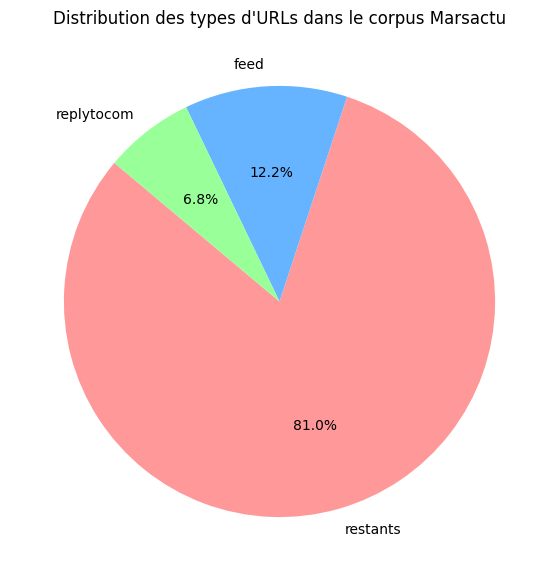

In [218]:
pattern_feed = r'/feed/$'
pattern_replytocom = r'replytocom=[0-9]*'

urls_articles=[]
url_feed=[]
url_replytocom=[]

stats_url = Counter()





with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        
        if record.rec_type != "response":
            continue

        url = record.rec_headers.get_header("WARC-Target-URI")

        if re.search(pattern_feed, url):
            url_feed.append(url)
            stats_url["feed"] += 1
        elif re.search(pattern_replytocom, url):
            url_replytocom.append(url)
            stats_url["replytocom"] += 1

        else:
            urls_articles.append(url)
            stats_url['restants'] += 1
            
counts = stats_url.values()
labels = stats_url.keys()


plt.figure(figsize=(10, 7))
plt.pie(counts, labels=labels, autopct="%1.1f%%", startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("Distribution des types d'URLs dans le corpus Marsactu")
plt.show()

En éliminant les URLs contenant `replytocom` et `feed`, on enlève environ 19% du corpus brut.

In [219]:
# En éliminant record contenant les url /feed/ et replytocom
# on analyse les terminaisons d'URL pour recenser les formats de fichiers présents.

pattern_feed = r'/feed/$'
pattern_replytocom = r'replytocom=[0-9]*'



with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        
        if record.rec_type != "response":
            continue

        url = record.rec_headers.get_header("WARC-Target-URI")

        if re.search(pattern_feed, url) or re.search(pattern_replytocom, url) :
            continue
        print(url[-6:])

tu.fr/
tenne/
rcoit/
anape/
750-e/
laise/
alpes/
t-moi/
nnage/
rgane/
ntini/
nchie/
uiete/
panne/
r-lom/
lhaud/
-coup/
erini/
donna/
tenne/
ncher/
ats-2/
-pblv/
tobre/
ctive/
ive/0/
-jour/
xamen/
haiti/
merde/
ument/
bians/
-nord/
alans/
ytes1/
monde/
nfant/
donna/
nna-2/
s-fou/
-sncm/
s-xvi/
zelle/
maine/
mores/
zelle/
e-vif/
ndage/
00_nw/
20h45/
eille/
allon/
panne/
hoer1/
ebook/
jpg-2/
1-jpg/
r-tf1/
n-ice/
omge2/
-lafp/
ianne/
nne-b/
veche/
-bk-2/
ondit/
-else/
-foot/
egion/
saire/
ionne/
ouest/
euzey/
fiche/
e-lom/
tclic/
belle/
ranee/
corse/
-soir/
eille/
haiti/
zelle/
laube/
es-24/
-paca/
-sncm/
a-pub/
lecom/
ecolo/
eille/
ainer/
urces/
inent/
n-vue/
rgane/
sier4/
lisle/
-soir/
r-42e/
acier/
alene/
-port/
n-vau/
nue-2/
/3275/
lader/
atac7/
eille/
/3381/
eille/
laise/
c2%bb/
-paye/
eille/
ancre/
ances/
zelle/
eille/
-midi/
/3600/
dages/
gebon/
evsky/
ecolo/
-tree/
audin/
ouges/
97000/
s-dit/
nerfs/
regle/
arles/
e-sdf/
ocies/
eille/
toire/
a-nage
pelle/
eille/
atour/
ligne/
berre/

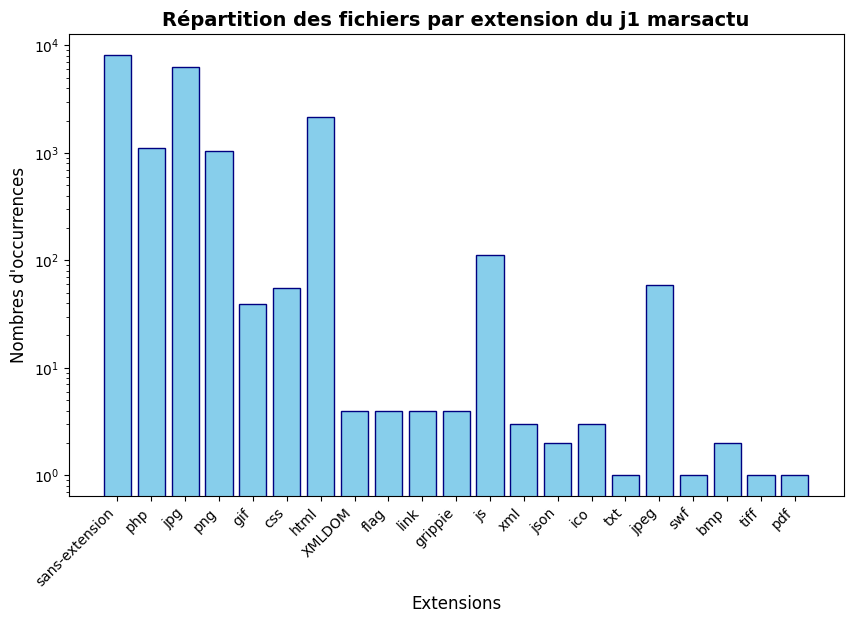

In [231]:
extension_counter = Counter()

record_counter=Counter() # On compte les records utilisés et les records non utilisés

pattern_feed = r'/feed/$'
pattern_replytocom = r'replytocom=[0-9]*'


pattern_extension = r'\.([a-z0-9]{2,8})(?:\?|#|$)'


with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        
        if record.rec_type != "response":
            record_counter["entête-warc"] += 1
            continue

        url = record.rec_headers.get_header("WARC-Target-URI")
        url = str(url)

        if re.search(pattern_feed, url) or re.search(pattern_replytocom, url) :
            record_counter["feed/replyto"] += 1
            continue
        
        record_counter["cleaned"] += 1
        
        match = re.search(pattern_extension, url, flags=re.IGNORECASE)
        if match:
            extension = match.group(1)
            extension_counter[f"{extension}"] += 1
            #print(extension)
        else:
            extension_counter["sans-extension"] += 1
            #print(url)

x_extensions = extension_counter.keys()
y_extension_count = extension_counter.values()

plt.figure(figsize=(10,6))
plt.bar(x_extensions,y_extension_count, color='skyblue', edgecolor='navy')
plt.yscale('log')

plt.title("Répartition des fichiers par extension du j1 marsactu", fontsize=14, fontweight='bold')
plt.xlabel("Extensions", fontsize=12)
plt.ylabel("Nombres d\'occurrences", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.show()






#### Lecture du graphique

La catégorie `sans-extension` correspond aux URLs sans extension de fichier.  Les catégories sans-extension et html sont les vraies pages d'articles au format `/AAAA/MM/JJ/slug/`, donc ce qui nous intéresse pour l'analyse de la ligne éditoriale.

Les autres extensions sont des ressources annexes : jpg, png et gif pour les images, css pour les feuilles de style, js pour les scripts, pdf pour les documents joints.

Pour le NLP on ne gardera que la catégorie `sans-extension` et `html`. Les images pourront être ré-utilisées plus tard si on veut creuser le côté visuel du média.

In [221]:
compteurs_records = record_counter.values()
nb_records_total = 0 
for count in compteurs_records:
    nb_records_total += count
print(nb_records_total) # On devrait avoir 23470



# Après nettoyage, comptons le nombre de fichiers sur lequel on travail
nb_records_a_exclure = record_counter["feed/replyto"]
print(nb_records_a_exclure)

nb_records_utiles = nb_records_total - nb_records_a_exclure -1 # -1 pour l'entête-warc
print(nb_records_utiles)

# Vérifiions que ce nombre est bon en sommant les occurrences
nb_records_avec_extension = 0
for count in y_extension_count:
    nb_records_avec_extension += count
print(nb_records_avec_extension)
    
    



23470
4450
19019
19019


## Codes de statut HTTP

On a regardé le nombre et le type des records mais pas si les pages ont été servies correctement par le serveur. Un record peut très bien être une page 404 ou une redirection 301/302 sans contenu utile. Pour l'analyse on ne gardera que les statuts 200.

In [222]:
http_status_counter = Counter()

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        status = record.http_headers.get_statuscode()
        http_status_counter[status] += 1

print(http_status_counter.most_common())

[('200', 22651), ('302', 766), ('301', 52)]


### Les redirections

On a 766 records en 302 (redirection temporaire) et 52 en 301 (redirection permanente), soit environ 3,5% du corpus. On regarde un exemple de chaque pour voir vers quoi ça pointe. Le header HTTP `Location` donne l'URL cible.

In [233]:
exemples_redirections = {"301": None, "302": None}

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        status = record.http_headers.get_statuscode()
        if status in exemples_redirections and exemples_redirections[status] is None:
            url = record.rec_headers.get_header("WARC-Target-URI")
            location = record.http_headers.get_header("Location")
            content_type = record.http_headers.get_header("Content-Type")
            body = record.content_stream().read().decode("utf-8", errors="replace")
            exemples_redirections[status] = {
                "url": url,
                "location": location,
                "content_type": content_type,
                "body": body,
            }
        if all(v is not None for v in exemples_redirections.values()):
            break

for status, ex in exemples_redirections.items():
    print(f"--Statut {status} ---")
    print(f"URL d'origine : {ex['url']}")
    print(f"Location      : {ex['location']}")
    print(f"Content-Type  : {ex['content_type']}")
    print(f"Body (500 premiers caractères) :")
    print(ex['body'][:500])
    print()

--Statut 301 ---
URL d'origine : http://www.marsactu.fr/2010/02/17/christophe-madrolle-va-t-il-traverser-le-vieux-port-a-la-nage
Location      : http://www.marsactu.fr/politique/christophe-madrolle-va-t-il-traverser-le-vieux-port-a-la-nage-24218.html
Content-Type  : text/html; charset=utf-8
Body (500 premiers caractères) :


--Statut 302 ---
URL d'origine : http://www.marsactu.fr/
Location      : https://marsactu.fr/
Content-Type  : text/html; charset=iso-8859-1
Body (500 premiers caractères) :
<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
<html><head>
<title>302 Found</title>
</head><body>
<h1>Found</h1>
<p>The document has moved <a href="https://marsactu.fr/">here</a>.</p>
<hr>
<address>Apache Server at marsactu.fr Port 80</address>
</body></html>




## Comparaison entre un record avec extension `.html` et un record sans extension

Dans le graphique des extensions, on a deux catégories qui peuvent correspondre à des pages d'articles : les URLs qui finissent par `.html` (nouveau format de Marsactu après la migration d'URL) et les URLs sans extension classées en `links` (ancien format `/AAAA/MM/JJ/slug/`). On regarde un exemple de chaque pour vérifier que les deux pointent bien vers du contenu HTML exploitable.

In [226]:
exemple_html = None
exemple_sans_extension = None

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        if record.http_headers.get_statuscode() != "200":
            continue

        url = record.rec_headers.get_header("WARC-Target-URI")

        if re.search(pattern_feed, url) or re.search(pattern_replytocom, url):
            continue

        match = re.search(pattern_extension, url, flags=re.IGNORECASE)

        if exemple_html is None and match and match.group(1).lower() == "html":
            content_type = record.http_headers.get_header("Content-Type")
            body = record.content_stream().read().decode("utf-8", errors="replace")
            exemple_html = {"url": url, "content_type": content_type, "body": body}

        elif exemple_sans_extension is None and match is None:
            content_type = record.http_headers.get_header("Content-Type")
            body = record.content_stream().read().decode("utf-8", errors="replace")
            exemple_sans_extension = {"url": url, "content_type": content_type, "body": body}

        if exemple_html and exemple_sans_extension:
            break

for label, ex in [("AVEC extension .html", exemple_html), ("SANS extension", exemple_sans_extension)]:
    print(f"========== {label} ==========")
    print(f"URL          : {ex['url']}")
    print(f"Content-Type : {ex['content_type']}")
    print(f"Body (500 premiers caractères) :")
    print(ex['body'][:500])
    print()

========== AVEC extension .html ==========
URL          : http://www.marsactu.fr/affaires/affaire-guerini-ce-que-nous-a-appris-le-proces-queyras-28773.html
Content-Type : text/html; charset=utf-8
Body (500 premiers caractères) :
<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 4.01 Transitional//EN" "http://www.w3.org/TR/html4/loose.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" xml:lang="fr" lang="fr" dir="ltr"
      xmlns:og="http://ogp.me/ns#"
      xmlns:fb="http://www.facebook.com/2008/fbml">
  <head>
<meta http-equiv="Content-Type" content="text/html; charset=utf-8" />
    <title>Affaire Guérini : ce que nous a appris le procès Queyras | Marsactu</title>
<meta http-equiv="Content-Type" content="text/html; charset=utf-8" 

========== SANS extension ==========
URL          : http://www.marsactu.fr/2009/12/22/a-marseille-quand-le-tramway-est-en-greve-personne-ne-sen-apercoit/
Content-Type : text/html; charset=UTF-8
Body (500 premiers caractères) :
<?xml version="1.0" encoding="UTF-8"?> <!D

## Filtrage progressif du corpus

On applique maintenant les filtres dans l'ordre et on compte combien de records sont éliminés à chaque étape. Au début on a tous les records du WARC, à la fin on doit avoir le corpus de travail prêt pour le NLP.

Les filtres dans l'ordre :

1. Enlever l'en-tête `warcinfo` (1 seul record, c'est juste les métadonnées du fichier WARC)
2. Enlever les URLs en `/feed/` et en `?replytocom=...` (doublons WordPress)
3. Ne garder que les records avec un statut HTTP 200 (enlever les redirections et erreurs)
4. Ne garder que les records dont le `Content-Type` est `text/html` (enlever images, CSS, JS, PDF, XML…)

In [227]:
compte_depart = 0
compte_filtres = Counter()
compte_final = 0

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        compte_depart += 1

        if record.rec_type != "response":
            compte_filtres["1. entête warcinfo"] += 1
            continue

        url = record.rec_headers.get_header("WARC-Target-URI")

        if re.search(pattern_feed, url) or re.search(pattern_replytocom, url):
            compte_filtres["2. /feed/ et ?replytocom="] += 1
            continue

        if record.http_headers.get_statuscode() != "200":
            compte_filtres["3. statut HTTP != 200"] += 1
            continue

        content_type = record.http_headers.get_header("Content-Type") or ""
        if not content_type.startswith("text/html"):
            compte_filtres["4. Content-Type != text/html"] += 1
            continue

        compte_final += 1

print(f"Compte de départ : {compte_depart}")
print()
print("Records éliminés à chaque filtre :")
compte_courant = compte_depart
for filtre, n in compte_filtres.items():
    compte_courant -= n
    print(f"  {filtre}  --  éliminés : {n}  --  restants : {compte_courant}")
print()
print(f"Compte final (corpus de travail) : {compte_final}")

Compte de départ : 23470

Records éliminés à chaque filtre :
  1. entête warcinfo  --  éliminés : 1  --  restants : 23469
  3. statut HTTP != 200  --  éliminés : 806  --  restants : 22663
  2. /feed/ et ?replytocom=  --  éliminés : 4450  --  restants : 18213
  4. Content-Type != text/html  --  éliminés : 8642  --  restants : 9571

Compte final (corpus de travail) : 9571


## Bilan de l'exploration

Le WARC fait 419 Mo et contient 23 470 records : 1 warcinfo et 23 469 réponses HTTP. Le crawl a été fait par la BnF avec un crawler propriétaire (`website-recover/3.0.0PFC30`). La période officielle annoncée est du 1er janvier 2011 au 31 décembre 2015, mais la première capture réelle date du 16 septembre 2011 et la dernière du 30 décembre 2015.

La distribution temporelle des captures est très inégale, avec environ 40% des records concentrés sur janvier 2012. Ça correspond à un crawl rétrospectif initial qui a aspiré tout le site existant à ce moment-là, incluant des articles publiés dès décembre 2009. L'analyse diachronique du contenu devra donc reposer sur la date de publication (lisible dans l'URL), pas sur la date de capture.

On a identifié deux familles de doublons : les URLs en `/feed/` (flux RSS des commentaires) et les URLs en `?replytocom=...` (copies WordPress quand un visiteur répond à un commentaire). En les éliminant on retire environ 19% du corpus brut.

Côté statuts HTTP, 96,5% des records sont des 200, 3,3% sont des 302 et 0,2% des 301. Ces redirections sont des traces intéressantes de l'évolution technique et éditoriale de Marsactu sur la période.

Pour la suite on exclut les URLs en `/feed/` et `?replytocom=`, et on ne garde que les records avec un statut 200 et un Content-Type `text/html`. Les images, CSS et JS sont conservées dans le WARC mais mises de côté pour l'analyse textuelle.
